# Eksperimen Dataset: Telco Customer Churn

**Nama**    : FirahMaulida  
**Course**  : Membangun Sistem Machine Learning — Dicoding  
**Dataset** : [Telco Customer Churn (IBM)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Python**  : 3.12.7  

---

## Tujuan
Notebook ini mendokumentasikan seluruh tahap eksplorasi dan preprocessing data sebelum masuk ke fase pelatihan model. Tahapan yang dilakukan:

1. **Loading Data** — memuat dan mengecek dataset mentah
2. **Exploratory Data Analysis (EDA)** — memahami distribusi, korelasi, dan pola data
3. **Data Cleaning** — menangani missing values dan tipe data yang tidak sesuai
4. **Feature Engineering** — menghapus fitur yang tidak relevan
5. **Preprocessing** — encoding dan scaling fitur


---
## 0. Import Library


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Gaya visualisasi
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Library berhasil diimpor!')

Library berhasil diimpor!


---
## 1. Loading Data

Dataset dimuat dari folder `namadataset_raw/`. Kita akan melihat lima baris pertama, tipe data setiap kolom, serta statistik deskriptif awal.


In [2]:
DATA_PATH = '../namadataset_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape dataset: {df.shape}')
df.head()

Shape dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('Info tipe data:')
df.info()

Info tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

In [4]:
print('Statistik deskriptif kolom numerik:')
df.describe()

Statistik deskriptif kolom numerik:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print('Jumlah nilai null per kolom:')
print(df.isnull().sum())
print()
print('Catatan: TotalCharges bertipe object — perlu dikonversi ke numerik terlebih dahulu.')

Jumlah nilai null per kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Catatan: TotalCharges bertipe object — perlu dikonversi ke numerik terlebih dahulu.


**Temuan awal:**
- Dataset memiliki **7.043 baris** dan **21 kolom**.
- Kolom `TotalCharges` bertipe *object* padahal seharusnya numerik — terdapat string kosong/spasi yang menyebabkan pandas tidak bisa otomatis mengidentifikasi tipenya.
- Tidak ada `NaN` yang tampak sebelum konversi; issue tersembunyi di kolom `TotalCharges`.


---
## 2. Exploratory Data Analysis (EDA)

Tiga visualisasi kunci untuk memahami dataset:
1. Distribusi target (`Churn`) → deteksi ketidakseimbangan kelas
2. Heatmap korelasi fitur numerik
3. Pengaruh jenis `Contract` terhadap `Churn`


### 2.1 Distribusi Target Variable (`Churn`)


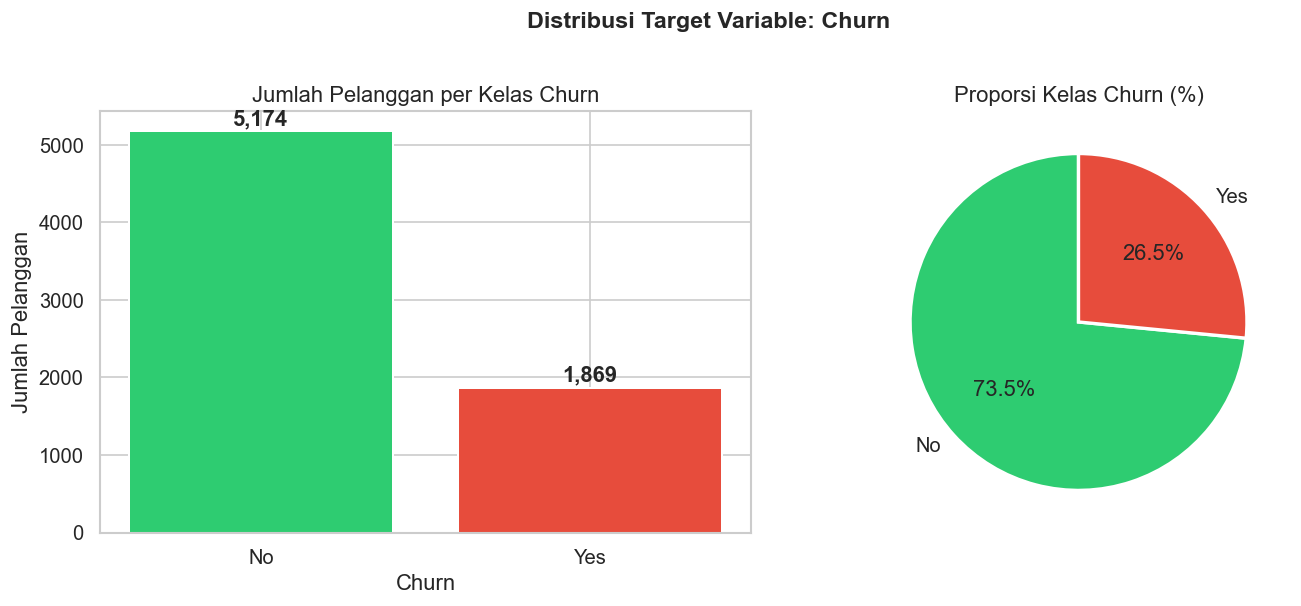


Distribusi Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Target Variable: Churn', fontsize=14, fontweight='bold', y=1.01)

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Jumlah Pelanggan per Kelas Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(
    churn_pct.values, labels=churn_pct.index,
    autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Proporsi Kelas Churn (%)')

plt.tight_layout()
plt.savefig('eda_01_distribusi_churn.png', bbox_inches='tight')
plt.show()
print(f'\nDistribusi Churn:\n{churn_counts}\n\nProporsi:\n{churn_pct.round(2)}')

**Insight:**  
Dataset mengalami **class imbalance** — hanya ~26.5% pelanggan yang churn (`Yes`) dan ~73.5% tidak churn (`No`). Pada fase pemodelan, perlu dipertimbangkan teknik resampling (SMOTE) atau penggunaan `class_weight='balanced'`.


### 2.2 Heatmap Korelasi Fitur Numerik


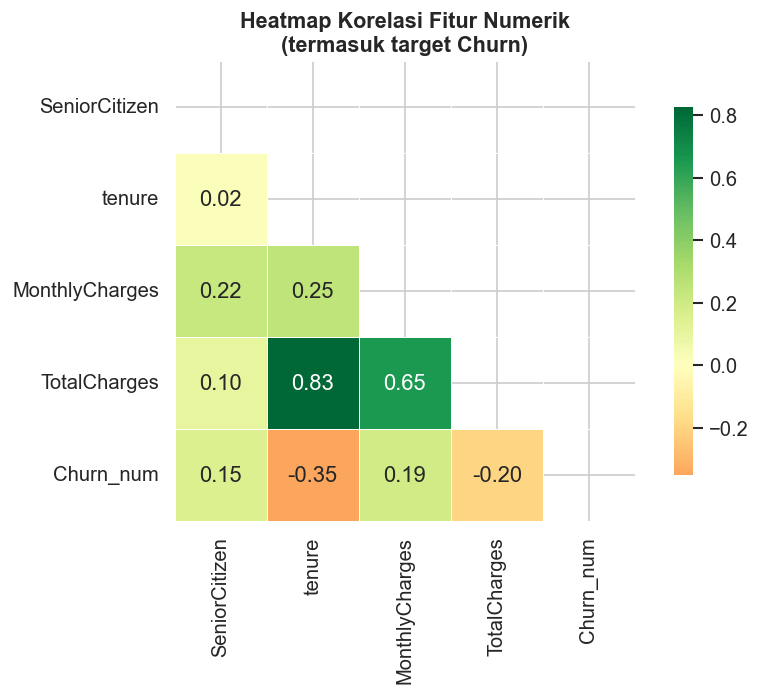

In [7]:
# Konversi sementara untuk keperluan EDA
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['Churn_num'] = (df_eda['Churn'] == 'Yes').astype(int)

numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
corr_matrix  = df_eda[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Heatmap Korelasi Fitur Numerik\n(termasuk target Churn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_korelasi.png', bbox_inches='tight')
plt.show()

**Insight:**
- `tenure` memiliki korelasi **negatif** terhadap `Churn` (−0.35): pelanggan lama cenderung tidak churn.
- `MonthlyCharges` berkorelasi **positif** dengan `Churn` (+0.19): tagihan bulanan tinggi → lebih mungkin churn.
- `TotalCharges` sangat berkorelasi dengan `tenure` (+0.83) — wajar karena pelanggan lama akumulasi tagihannya besar.


### 2.3 Tipe Kontrak vs. Churn Rate


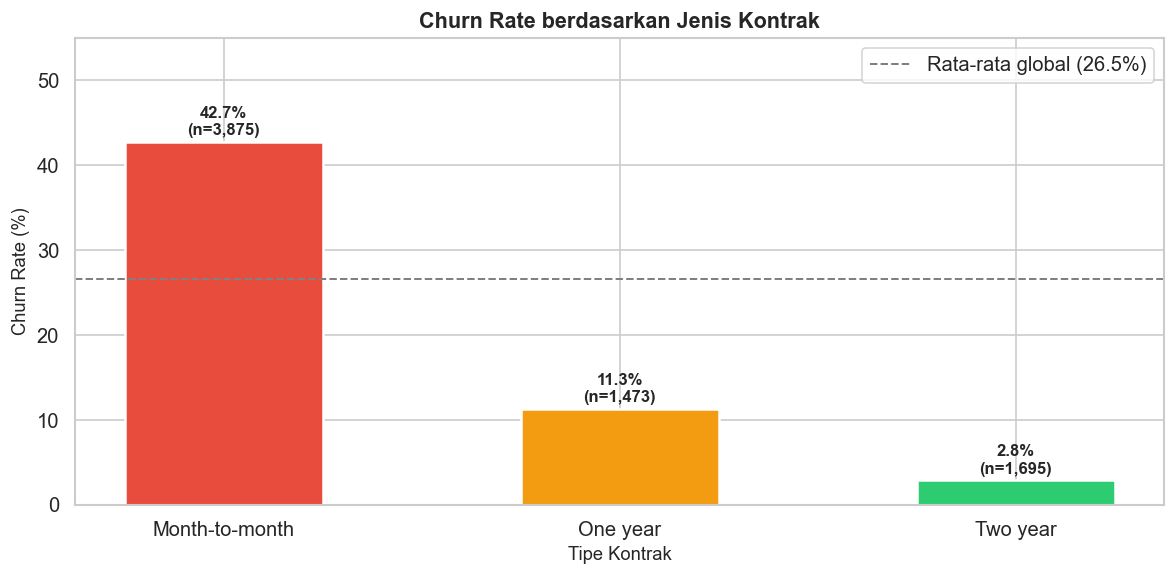

      Contract  Churn_Rate_Pct  Total
Month-to-month       42.709677   3875
      One year       11.269518   1473
      Two year        2.831858   1695


In [8]:
contract_churn = df_eda.groupby('Contract')['Churn_num'].agg(['mean', 'count']).reset_index()
contract_churn.columns = ['Contract', 'Churn_Rate', 'Total']
contract_churn['Churn_Rate_Pct'] = contract_churn['Churn_Rate'] * 100
contract_churn = contract_churn.sort_values('Churn_Rate_Pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

palette = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(
    contract_churn['Contract'],
    contract_churn['Churn_Rate_Pct'],
    color=palette, edgecolor='white', linewidth=1.5, width=0.5
)

# Anotasi nilai dan jumlah sampel
for bar, row in zip(bars, contract_churn.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
        f'{row.Churn_Rate_Pct:.1f}%\n(n={row.Total:,})',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Churn Rate berdasarkan Jenis Kontrak', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipe Kontrak', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 55)
ax.axhline(y=churn_pct['Yes'], color='gray', linestyle='--', linewidth=1.2, label=f'Rata-rata global ({churn_pct["Yes"]:.1f}%)')
ax.legend()

plt.tight_layout()
plt.savefig('eda_03_contract_vs_churn.png', bbox_inches='tight')
plt.show()

print(contract_churn[['Contract', 'Churn_Rate_Pct', 'Total']].to_string(index=False))

**Insight:**  
Pelanggan dengan kontrak **Month-to-month** memiliki churn rate tertinggi (~42.7%), jauh di atas rata-rata global. Sebaliknya, pelanggan dengan **Two year** contract hampir tidak pernah churn (~2.8%). Fitur `Contract` kemungkinan akan menjadi salah satu prediktor paling penting dalam model.


---
## 3. Data Cleaning & Feature Engineering

Berdasarkan temuan EDA, langkah cleaning yang diperlukan:
1. Konversi `TotalCharges` dari *object* ke *float64*
2. Isi missing values dengan **median** (robust terhadap outlier)
3. Hapus kolom `customerID` (identifier, tidak relevan untuk model)


In [9]:
df_clean = df.copy()

# --- Langkah 1: Konversi TotalCharges ---
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f'NaN di TotalCharges setelah konversi: {df_clean["TotalCharges"].isna().sum()}')

# --- Langkah 2: Isi missing values dengan median ---
median_tc = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_tc)
print(f'Median TotalCharges yang digunakan: {median_tc:.2f}')
print(f'NaN di TotalCharges setelah imputation: {df_clean["TotalCharges"].isna().sum()}')

# --- Langkah 3: Hapus customerID ---
df_clean.drop(columns=['customerID'], inplace=True)

print(f'\nShape setelah cleaning: {df_clean.shape}')
print(f'Kolom tersisa: {list(df_clean.columns)}')

NaN di TotalCharges setelah konversi: 11
Median TotalCharges yang digunakan: 1397.47
NaN di TotalCharges setelah imputation: 0

Shape setelah cleaning: (7043, 20)
Kolom tersisa: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


---
## 4. Preprocessing

Tiga tahap preprocessing:
1. **Label Encoding** — fitur biner (2 nilai unik)
2. **One-Hot Encoding** — fitur kategori multi-label
3. **StandardScaler** — fitur numerik kontinyu


### 4.1 Label Encoding (Fitur Biner)


In [10]:
BINARY_FEATURES = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn',
]

df_encoded = df_clean.copy()
le = LabelEncoder()

for col in BINARY_FEATURES:
    original = df_encoded[col].unique().tolist()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoded  = sorted(df_encoded[col].unique().tolist())
    print(f'{col:18s}: {original} → {encoded}')

print(f'\nShape setelah Label Encoding: {df_encoded.shape}')

gender            : ['Female', 'Male'] → [0, 1]
Partner           : ['Yes', 'No'] → [0, 1]
Dependents        : ['No', 'Yes'] → [0, 1]
PhoneService      : ['No', 'Yes'] → [0, 1]
PaperlessBilling  : ['Yes', 'No'] → [0, 1]
Churn             : ['No', 'Yes'] → [0, 1]

Shape setelah Label Encoding: (7043, 20)


### 4.2 One-Hot Encoding (Fitur Multi-Label)


In [11]:
MULTICLASS_FEATURES = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod',
]

print('Kolom sebelum OHE:', df_encoded.shape[1])
df_ohe = pd.get_dummies(df_encoded, columns=MULTICLASS_FEATURES, drop_first=False)

# Konversi bool ke int
bool_cols = df_ohe.select_dtypes(include='bool').columns
df_ohe[bool_cols] = df_ohe[bool_cols].astype(int)

print('Kolom sesudah OHE:', df_ohe.shape[1])
print(f'\nShape setelah OHE: {df_ohe.shape}')
df_ohe.head(3)

Kolom sebelum OHE: 20
Kolom sesudah OHE: 41

Shape setelah OHE: (7043, 41)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1


### 4.3 StandardScaler (Fitur Numerik)


In [12]:
NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']

df_final = df_ohe.copy()
scaler   = StandardScaler()

df_final[NUMERIC_FEATURES] = scaler.fit_transform(df_final[NUMERIC_FEATURES])

print('Statistik fitur numerik setelah scaling:')
print(df_final[NUMERIC_FEATURES].describe().round(4))

Statistik fitur numerik setelah scaling:
          tenure  MonthlyCharges  TotalCharges
count  7043.0000       7043.0000     7043.0000
mean     -0.0000         -0.0000       -0.0000
std       1.0001          1.0001        1.0001
min      -1.3182         -1.5459       -0.9991
25%      -0.9517         -0.9725       -0.8298
50%      -0.1373          0.1857       -0.3905
75%       0.9215          0.8338        0.6643
max       1.6137          1.7944        2.8267


---
## 5. Simpan Hasil Preprocessing


In [13]:
import os

output_dir  = '../preprocessed_output'
output_path = os.path.join(output_dir, 'telco_churn_preprocessed.csv')

os.makedirs(output_dir, exist_ok=True)
df_final.to_csv(output_path, index=False)

print(f'Dataset preprocessed berhasil disimpan!')
print(f'Path  : {output_path}')
print(f'Shape : {df_final.shape}')
df_final.head()

Dataset preprocessed berhasil disimpan!
Path  : ../preprocessed_output\telco_churn_preprocessed.csv
Shape : (7043, 41)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,1,...,1,0,0,1,0,0,0,0,1,0


---
## 6. Ringkasan Eksperimen

| Tahap | Aksi | Hasil |
|-------|------|-------|
| Loading | Memuat CSV mentah | 7.043 baris, 21 kolom |
| Data Cleaning | Konversi TotalCharges + imputasi median + hapus customerID | 7.043 baris, 20 kolom |
| Label Encoding | Encode 6 fitur biner | — |
| One-Hot Encoding | Encode 10 fitur multi-label | Bertambah menjadi ~33 kolom |
| StandardScaler | Scale 3 fitur numerik | Mean ≈ 0, Std ≈ 1 |
| **Output akhir** | CSV siap pakai untuk modeling | **7.043 baris, 33 kolom** |

Dataset telah siap untuk masuk ke fase pelatihan model. Pastikan untuk mempertimbangkan **class imbalance** pada target `Churn` saat membangun model.
